In [1]:
from MITgcmutils import mds
from MITgcmutils import mnc
import matplotlib as mpl
from netCDF4 import Dataset
from matplotlib import pyplot as plt
import numpy as np
import gsw
from matplotlib.colors import LinearSegmentedColormap
from scipy.ndimage import gaussian_filter
import matplotlib.colors as mcolors

def makeColors(seedColor, n):
    color1 = 'xkcd:light ' + seedColor
    color2 = 'xkcd:dark ' + seedColor
    rlin = np.linspace(mcolors.to_rgb(color1)[0],mcolors.to_rgb(color2)[0],n)
    glin = np.linspace(mcolors.to_rgb(color1)[1],mcolors.to_rgb(color2)[1],n)
    blin = np.linspace(mcolors.to_rgb(color1)[2],mcolors.to_rgb(color2)[2],n)
    colors = np.stack((rlin,glin,blin), axis=0)
    return colors


In [2]:

def meltRate(strength,n):
    #switch from 
    n = 25
    x = np.linspace(0,1,n)
    baseLine = .6 -.4*x
    arc = .5 + 50*(x-.46)**6

    min = .4
    max = .6587
    if(strength < min):
        return baseLine*strength/min
    elif(strength < max):
        r = (strength - min)/(max-min)
        return baseLine*(1-r) + arc*(r)
    else:
        return arc*strength/max
 


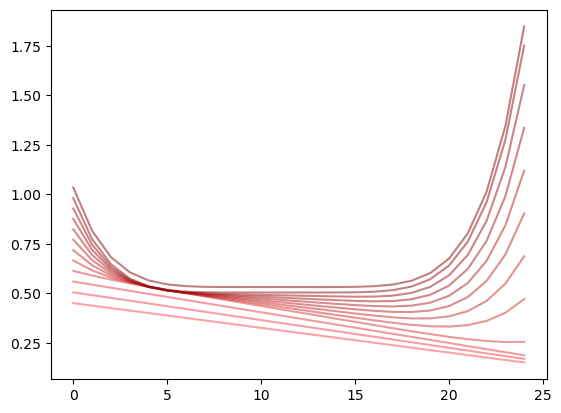

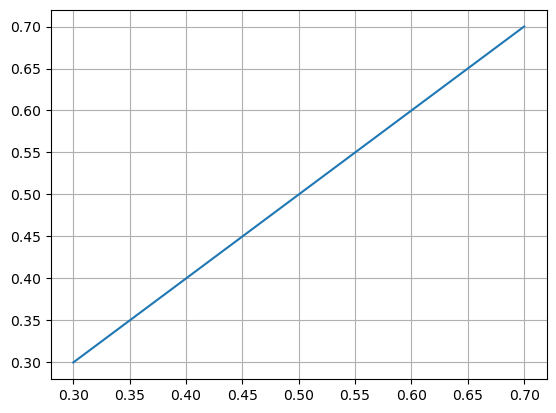

In [3]:
# plt.plot(baseLine,'r')
# plt.plot(arc,'b')
m = 12
colors = makeColors('red',m)
avgMelt = np.zeros(m)
r = np.linspace(.3,.7,m)
n=24
for i in range(m):
    avgMelt[i] = np.mean(meltRate(r[i],n))
    plt.plot(meltRate(r[i],n),color=colors[:,i],alpha=.5)

plt.figure()
plt.plot(r,avgMelt)
plt.grid()
# print(avgMelt)
